In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy.stats import norm
from scipy.integrate import quad

## a)

In [5]:
df = pd.read_csv('GlacierElevation.txt', sep=' ', header=1, names=['elevation'])
df

,elevation
0,4120.0
1,5120.0
2,5000.0
3,2480.0
4,2740.0
...,...
994,5304.0
995,4816.0
996,5182.0
997,5121.0


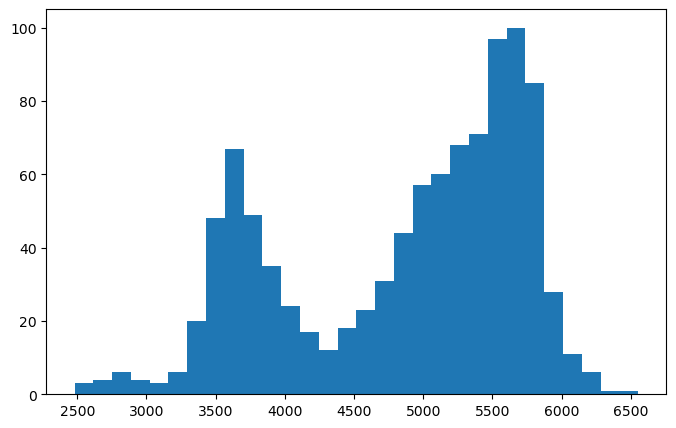

In [30]:
elevation = df['elevation']
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(elevation, bins=30);

In [ ]:
def doubleGauss(x, w, mu1, sigma1, mu2, sigma2):
    return w*norm.pdf(x, mu1, sigma1) + (1-w)*norm.pdf(x, mu2, sigma2)


def tripleGauss(x, w1, w2, mu1, sigma1, mu2, sigma2, mu3, sigma3):
    return w1* norm.pdf(x, mu1, sigma1) + w2*norm.pdf(x, mu2, sigma2) + (1-w1-w2)*norm.pdf(x, mu3, sigma3)


In [99]:
c1 = cost.UnbinnedNLL(elevation, doubleGauss)
m1 = Minuit(c1, w=0.3, mu1=3650, sigma1=100, mu2=5350, sigma2=100)
m1.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.59e+04                   │              Nfcn = 251              │
│ EDM = 2.93e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ w      │   0.312   │   0.017   │            │            │         │         │       │
│ 1 │ mu1    │  3.718e3  │  0.029e3  │            │            │         │         │       │
│ 2 │ sigma1 │    379    │    23     │            │            │         │         │       │
│ 3 │ mu2    │  5.377e3  │  0.018e3  │            │            │         │         │       │
│ 4 │ sigma2 │    393    │    14     │            │            │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬───────────────────────────────────────────────────┐
│        │         w       mu1    sigma1       mu2    sigma2 │
├────────┼───────────────────────────────────────────────────┤
│      w │  0.000271 144.89e-3 129.18e-3  69.03e-3 -62.68e-3 │
│    mu1 │ 144.89e-3       842     0.3e3    0.18e3   -0.16e3 │
│ sigma1 │ 129.18e-3     0.3e3       553    0.15e3   -0.13e3 │
│    mu2 │  69.03e-3    0.18e3    0.15e3       311   -0.08e3 │
│ sigma2 │ -62.68e-3   -0.16e3   -0.13e3   -0.08e3       189 │
└────────┴───────────────────────────────────────────────────┘

In [104]:
c2 = cost.UnbinnedNLL(elevation, tripleGauss)
m2 = Minuit(c2, w1 = 0.3, w2=0.5, mu1=3750, sigma1=100, mu2= 5000, sigma2=100, mu3=5600, sigma3=50)
m2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.583e+04                  │              Nfcn = 488              │
│ EDM = 4.47e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ w1     │   0.297   │   0.016   │            │            │         │         │       │
│ 1 │ w2     │   0.511   │   0.034   │            │            │         │         │       │
│ 2 │ mu1    │  3.683e3  │  0.025e3  │            │            │         │         │       │
│ 3 │ sigma1 │    351    │    20     │            │            │         │         │       │
│ 4 │ mu2    │  5.234e3  │  0.035e3  │            │            │         │         │       │
│ 5 │ sigma2 │    414    │    18     │            │            │         │         │       │
│ 6 │ mu3    │  5.688e3  │  0.018e3  │            │            │         │         │       │
│ 7 │ sigma3 │    135    │    21     │            │            │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬─────────────────────────────────────────────────────────────────────────────────┐
│        │        w1        w2       mu1    sigma1       mu2    sigma2       mu3    sigma3 │
├────────┼─────────────────────────────────────────────────────────────────────────────────┤
│     w1 │  0.000251  -0.15e-3  94.63e-3  78.87e-3  97.91e-3 -60.34e-3  19.75e-3 -18.28e-3 │
│     w2 │  -0.15e-3   0.00116    0.0014   -0.0033    0.7457    0.0902    0.1846   -0.4836 │
│    mu1 │  94.63e-3    0.0014       640     0.2e3     0.2e3   -0.13e3    0.04e3        -0 │
│ sigma1 │  78.87e-3   -0.0033     0.2e3       387     0.2e3   -0.10e3    0.03e3        -0 │
│    mu2 │  97.91e-3    0.7457     0.2e3     0.2e3  1.21e+03   -0.05e3    0.13e3    -0.4e3 │
│ sigma2 │ -60.34e-3    0.0902   -0.13e3   -0.10e3   -0.05e3       313   -0.08e3   -0.03e3 │
│    mu3 │  19.75e-3    0.1846    0.04e3    0.03e3    0.13e3   -0.08e3       317   -0.12e3 │
│ sigma3 │ -18.28e-3   -0.4836        -0        -0    -0.4e3   -0.03e3   -0.12e3       430 │
└────────┴─────────────────────────────────────────────────────────────────────────────────┘

The assignment explicitly states "Plot the total probability distribution function for each hypothesis". Therefore only the total probability distribution function for each hypothesis has been plotted and not the individual Gaussian distributions.

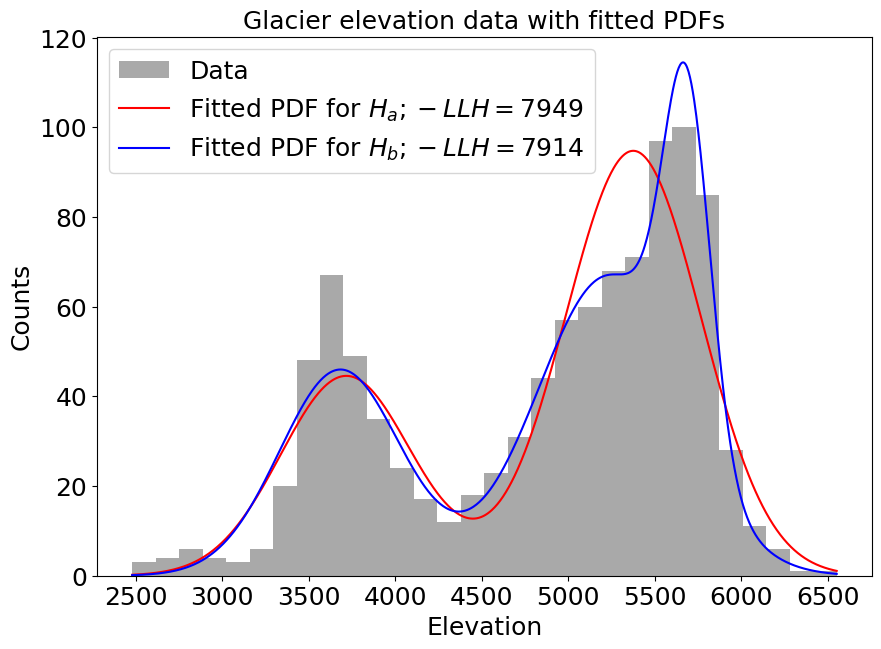

In [109]:
fig, ax = plt.subplots(figsize=(10, 7))

xmin = 2480
xmax = 6553
xx = np.linspace(xmin, xmax, 1000)
Nbins = 30
binwidth = (xmax - xmin) / Nbins
ax.hist(elevation, bins=Nbins, range=(xmin, xmax), color='darkgray', label='Data')

ax.plot(xx, doubleGauss(xx, *m1.values[:])*len(elevation)*binwidth, 'r-', label=fr'Fitted PDF for $H_a;  -LLH = {m1.fval/2:.0f}$')
ax.plot(xx, tripleGauss(xx, *m2.values[:])*len(elevation)*binwidth, 'b-', label=fr'Fitted PDF for $H_b; -LLH = {m2.fval/2:.0f}$')
ax.legend(fontsize=18);
ax.set_xlabel('Elevation', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Glacier elevation data with fitted PDFs', fontsize=18);
fig.savefig("4a.pdf");

## b)

In [107]:
from scipy.stats import chi2

lambVal = m1.fval - m2.fval
print(f"-2ln(λ) for data: {lambVal:.0f}")
pVal = chi2.sf(lambVal, df=3)
print(pVal)
print(f"The p-value for the hypothesis test is {pVal:.20f}")

-2ln(λ) for data: 71
2.232772644789103e-15
The p-value for the hypothesis test is 0.00000000000000223277


In [ ]:
z = norm.ppf(1 - pVal/2)
print(z)

7.928367942870712
